In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


# 1. Load the dataset

In [45]:
df = pd.read_csv("prabhsimrat_logs.csv")


In [46]:
df

,timestamp,cpuUsage,cpuTemperature,ramUsage,networkConnections,processCount,cpuPackagePower,cpuAverageClock
0,2026-07-01 02:30:53.975169600,27.4,82.9,71.33,236,269,31.3,3169
1,2026-07-01 02:30:57.909829600,8.3,71.3,71.70,237,269,15.3,3860
2,2026-07-01 02:31:00.960654700,15.5,75.0,71.64,239,270,21.4,4261
3,2026-07-01 02:31:03.999124400,43.9,85.6,71.67,236,270,41.5,3829
4,2026-07-01 02:31:07.045752800,49.6,91.9,72.76,238,270,42.9,3677
...,...,...,...,...,...,...,...,...
16356,2026-07-02 08:16:42.986522700,83.7,73.5,63.37,210,309,55.2,4217
16357,2026-07-02 08:16:44.590380900,99.9,82.1,64.12,268,307,58.5,4217
16358,2026-07-02 08:16:46.139693100,99.9,82.1,63.86,241,303,58.5,4214
16359,2026-07-02 08:16:47.673560300,21.6,79.0,63.57,271,305,29.6,3980


# 2. Selecting the features and target variables

We exclude the timestamp from training but keep it ordered sequentially

In [47]:
feature_cols = ['cpuUsage', 'ramUsage', 'networkConnections', 'processCount', 'cpuPackagePower', 'cpuAverageClock']
target_col = 'cpuTemperature'

# 3. Scale the data independently to prevent data leakage

In [48]:
scaler_X = MinMaxScaler(feature_range=(0,1))
scaler_Y = MinMaxScaler(feature_range=(0,1))

scaled_X = scaler_X.fit_transform(df[feature_cols])
scaled_Y = scaler_Y.fit_transform(df[[target_col]])

# 4. Create the sequence windows

In [49]:
def create_dataset(X_data, y_data, lookback = 10):
    X,y = [], []
    for i in range(len(X_data)-lookback):
        X.append(X_data[i: i+lookback])
        y.append(y_data[i+lookback])
        
    return np.array(X), np.array(y)

Lets lookback at the last 15 log entries to predict the next temperature step

In [50]:
lookback_window = 8
X,y = create_dataset(scaled_X, scaled_Y, lookback = lookback_window)

# 5. Split the dataset into Test/train sequentially, We cannot shuffle time series data randomly

In [51]:
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape} ")
print(f"y_train shape: {y_train.shape} ")

X_train shape: (13082, 8, 6) 
y_train shape: (13082, 1) 


# 6. Build the Regression LSTM Model

In [52]:
model = Sequential()

# First LSTM Layer: input shape requires (window_size, num_features)
model.add(LSTM(64, return_sequences=True, input_shape= (X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) #to prevent overfitting

# Second LSTM Layer
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))

# Dense Output Layer: 1 node for predicting a continuous temperature value
model.add(Dense(1))

# Compile using Mean Squared Error (standard for numeric regression)
model.compile(loss= 'mean_squared_error', optimizer = "adam", metrics = ['mae'])
model.summary()

/media/rehnoor/48984F97984F8284/Learning LSTM/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 8, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,265 (200.25 KB)

 Trainable params: 51,265 (200.25 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Train the Model

In [53]:
history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0225 - mae: 0.0954 - val_loss: 0.0049 - val_mae: 0.0380
Epoch 2/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0068 - mae: 0.0623 - val_loss: 0.0041 - val_mae: 0.0330
Epoch 3/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0060 - mae: 0.0582 - val_loss: 0.0040 - val_mae: 0.0335
Epoch 4/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0054 - mae: 0.0544 - val_loss: 0.0033 - val_mae: 0.0254
Epoch 5/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0050 - mae: 0.0518 - val_loss: 0.0032 - val_mae: 0.0239
Epoch 6/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0046 - mae: 0.0490 - val_loss: 0.0043 - val_mae: 0.0398
Epoch 7/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0042 - mae: 0.0467 - val_loss: 0.0030 - val_mae: 0.0221
Epoch 8/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0040 - mae: 0.0450 - val_loss: 0.0032 - val_mae: 0.0287
Epoch 9/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - lo

Evaluating the model

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [55]:
# Step 1: Generate predictions on the test set
y_pred_scaled = model.predict(X_test)

# Step 2: Reverse the scaling transformation
y_pred = scaler_Y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_Y.inverse_transform(y_test) # No reshape tricks needed!

# Step 3: Compute Evaluation Metrics
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("----Test Set Performance----")
print(f"Mean Absolute Error (MAE): {mae:.2f} °C")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °C")
print(f"R² Score (Variance Explained): {r2:.4f}")

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
----Test Set Performance----
Mean Absolute Error (MAE): 2.00 °C
Root Mean Squared Error (RMSE): 5.09 °C
R² Score (Variance Explained): 0.8076


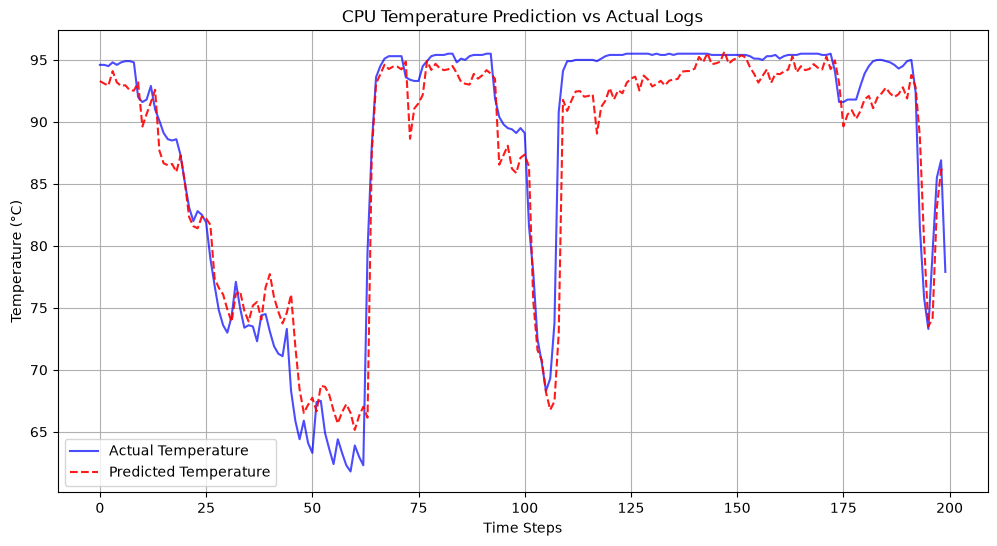

In [44]:
# Step 4: Plot Actual vs Predicted Temperature (First 200 points for clarity)
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual[:200], label='Actual Temperature', color='blue', alpha=0.7)
plt.plot(y_pred[:200], label='Predicted Temperature', color='red', linestyle='--', alpha=0.9)
plt.title('CPU Temperature Prediction vs Actual Logs')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

Testing Model trained on prabhsimrat_logs.csv on manan_logs.csv which are taken on different hardware to see generalization capability of our model.

In [56]:
df_manan = pd.read_csv('manan_logs.csv')

633/633 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
==== PERFORMANCE ON MANAN'S LAPTOP ====
Mean Absolute Error (MAE): 3.53 °C
Root Mean Squared Error (RMSE): 4.83 °C
R² Score (Variance Explained): 0.8403


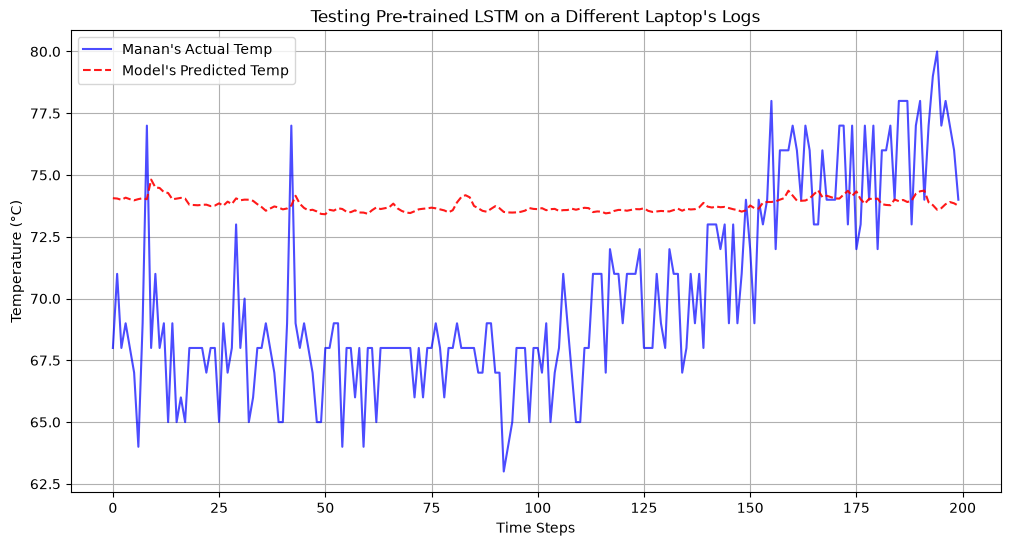

In [ ]:
scaled_X_manan = scaler_X.transform(df_manan[feature_cols])
scaled_Y_manan = scaler_Y.transform(df_manan[[target_col]])

X_manan, y_manan = create_dataset(scaled_X_manan, scaled_Y_manan, lookback=lookback_window)
y_pred_scaled_manan = model.predict(X_manan)

# Reversing the Scaling
y_pred_manan = scaler_Y.inverse_transform(y_pred_scaled_manan)
y_actual_manan = scaler_Y.inverse_transform(y_manan)

# Step 6: Compute performance metrics on the new hardware
mse_m = mean_squared_error(y_actual_manan, y_pred_manan)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_actual_manan, y_pred_manan)
r2_m = r2_score(y_actual_manan, y_pred_manan)

print("===== PERFORMANCE ON MANAN'S LAPTOP ====")
print(f"Mean Absolute Error (MAE): {mae_m:.2f} °C")
print(f"Root Mean Squared Error (RMSE): {rmse_m:.2f} °C")
print(f"R² Score (Variance Explained): {r2_m:.4f}")

# Step 7: Plot actual vs predicted for the new machine
plt.figure(figsize=(12, 6))
plt.plot(y_actual_manan[:200], label="Manan's Actual Temp", color='blue', alpha=0.7)
plt.plot(y_pred_manan[:200], label="Model's Predicted Temp", color='red', linestyle='--', alpha=0.9)
plt.title("Testing Pre-trained LSTM on a Different Laptop's Logs")
plt.xlabel("Time Steps")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()